# Laboratorio 6: Afinando la Máquina - Optimización y Regularización
**Maestría en Inteligencia de Negocios**

---

## 1. Contexto de Negocio

En la sesión anterior, demostramos que una Red Neuronal puede competir con modelos tradicionales. Sin embargo, nuestro prototipo era inestable: a veces aprendía muy bien, otras veces memorizaba los datos (overfitting).

**El Reto de Hoy:**
Transformar ese prototipo en un **modelo de producción**. Necesitamos una red que:
1.  Sea **robusta**: Que generalice bien a nuevos clientes (usando Dropout).
2.  Sea **rápida**: Que converja en menos tiempo (usando Batch Normalization).
3.  Sea **autónoma**: Que decida cuándo dejar de aprender (usando Early Stopping).

Utilizaremos nuevamente el dataset de **Marketing Bancario** para medir la mejora incremental.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Deep Learning (Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Configuración
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

## 2. Pipeline de Datos (Express)
Ejecutaremos la carga y limpieza de datos de forma compacta para centrarnos en la arquitectura.

In [2]:
# Carga y Preprocesamiento
try:
    df = pd.read_csv('../data/bank-additional-full.csv', sep=';')
except FileNotFoundError:
    print("⚠️ Cargando dataset sintético para demostración...")
    from sklearn.datasets import make_classification
    X_dummy, y_dummy = make_classification(n_samples=5000, n_features=20, random_state=42)
    df = pd.DataFrame(X_dummy, columns=[f'feat_{i}' for i in range(20)])
    df['y'] = np.where(y_dummy==1, 'yes', 'no')

df['target'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df = df.drop(columns=['y'])

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('target')

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int) #no puede haber booleanos, ni strings

X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Dataset listo: {X_train.shape[0]} muestras de entrenamiento, {X_train.shape[1]} características.")

Dataset listo: 32950 muestras de entrenamiento, 53 características.


## 3. Diseñando Arquitecturas

Vamos a definir dos modelos para competir:
1.  **Modelo Base:** Una red densa estándar, propensa a memorizar.
2.  **Modelo Robusto:** La misma red, pero con `Dropout` y `BatchNormalization`.

In [3]:
# def build_base_model(input_dim): La función recibe "input_dim", que es el número de características (columnas)
# que tiene tu dataset (por ejemplo, si tienes 20 variables predictoras, input_dim será 20).

# El modelo es secuencial, lo que significa que las capas se apilan una tras otra en orden lineal.
# Capa 1(Capa de Entrada + Oculta) -> 256 neuronas, función de activación ReLU
# Capa 2(Oculta) -> 128 neuronas, función de activación ReLU
# Capa 3(Oculta) -> 64 neuronas, función de activación ReLU
# Capa de Salida -> 1 neurona, función de activación Sigmoide (adecuada para clasificación binaria)

def build_base_model(input_dim):
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# El orden estándar en arquitecturas modernas es:

# 1. Dense: Realiza el cálculo lineal.
# 2. BatchNormalization: Normaliza esos resultados antes de que se distorsionen por la activación.
# 3. Activation: Aplica la no linealidad (relu) a los datos ya normalizados.
# [!IMPORTANT] Si incluyes activation='relu' dentro de Dense, no podrías poner la Normalización de Lote 
# antes de la activación, lo cual es la práctica recomendada para que el modelo sea más estable.

def build_robust_model(input_dim):
    # Arquitectura moderna: Dense -> BatchNorm -> Activation -> Dropout
    model = keras.Sequential([
        # Capa 1
        layers.Dense(256, input_shape=(input_dim,)),
        layers.BatchNormalization(), # Estabiliza la distribución
        layers.Activation('relu'),
        layers.Dropout(0.4),         # Apaga 40% de neuronas aleatoriamente
        
        # Capa 2
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        # Capa 3
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        
        # Salida
        layers.Dense(1, activation='sigmoid')
    ])
    return model

## 4. Experimento: El Efecto de la Regularización

Entrenaremos ambos modelos durante muchas épocas (100) para forzar el sobreajuste y ver cómo se comportan.

In [4]:
# Configuración del Experimento
INPUT_DIM = X_train.shape[1]
EPOCHS = 100 #Número de veces que el modelo verá todo el dataset (backpropagation - ir y venir)
BATCH_SIZE = 128 #Número de muestras que el modelo verá antes de actualizar los pesos (gradiente descendente)

model_base = build_base_model(INPUT_DIM)
model_robust = build_robust_model(INPUT_DIM)

# Compilamos con el mismo optimizador para ser justos

# Es el momento en que le dices a Keras: "Ya tenemos los planos (arquitectura), 
# ahora dime cómo vamos a aprender y cómo vamos a medir el éxito".
# (optimizer='adam') -> Es el algoritmo que actualiza los pesos de la red para reducir el error.
# --> Adam es el estándar de oro actualmente porque combina las mejores características de 
# otros optimizadores (como Momentum y RMSProp).
# --> Es "autoadaptativo": ajusta automáticamente qué tan grandes o pequeños deben ser 
# los pasos (learning rate) para cada neurona individualmente.

# (loss='binary_crossentropy') -> Es la función de pérdida adecuada para clasificación binaria.
# --> Calcula la "distancia" entre la probabilidad que predijo el modelo (ej. 0.8) y la etiqueta real (ej. 1). 
# El objetivo de la red es que este número llegue lo más cerca posible a cero.

# (metrics=['AUC']) --> Es el indicador que tú usas para evaluar el desempeño, pero que el modelo no usa para entrenar.

# Cuando ejecutas ese comando, TensorFlow realiza tres acciones invisibles:

# 1. Construye el Grafo: Crea el camino matemático por donde viajarán los datos.

# 2. Prepara el Autograd: Configura el motor que calculará las derivadas 
# (el cálculo necesario para el backpropagation).

# 3. Verifica la Integridad: Si tu capa de salida tuviera 10 neuronas pero usas una pérdida binaria, 
# .compile te lanzaría un error en este punto.

model_base.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
model_robust.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

# el comando .fit es el que inicia el proceso de entrenamiento.
# (validation_split=0.2) --> Al final de cada época, el modelo se pone a prueba con este 20% que no conoce.
# (batch_size=BATCH_SIZE) --> El modelo no mira los miles de registros de golpe. 
# Mira 128 registros, calcula el error, actualiza sus pesos (gradiente descendente) 
# y pasa a los siguientes 128. Esto hace que el entrenamiento sea eficiente en memoria.
# (verbose=0) --> No muestra el progreso en pantalla para no saturar la salida.
# Sin embargo, como el entrenamiento puede tardar unos segundos o minutos, 
# a veces es recomendable usar 'verbose=1' para ver la barra de progreso.

print("1. Entrenando Modelo Base (sin frenos)...")
history_base = model_base.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

print("2. Entrenando Modelo Robusto (con regularización)...")
history_robust = model_robust.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)
print("¡Entrenamiento completado!")

# (history_base) y (history_robust) son objetos (diccionarios) que contienen el historial 
# de entrenamiento de cada modelo. Incluyen métricas como la pérdida y el AUC tanto para 
# los datos de entrenamiento como para los datos de validación a lo largo de las épocas.

c:\Users\HP ENVY\miniconda3\envs\mlnn2526\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1. Entrenando Modelo Base (sin frenos)...
2. Entrenando Modelo Robusto (con regularización)...
¡Entrenamiento completado!


### Análisis Visual: Curvas de Aprendizaje
Esta es la herramienta de diagnóstico más importante para un Data Scientist.

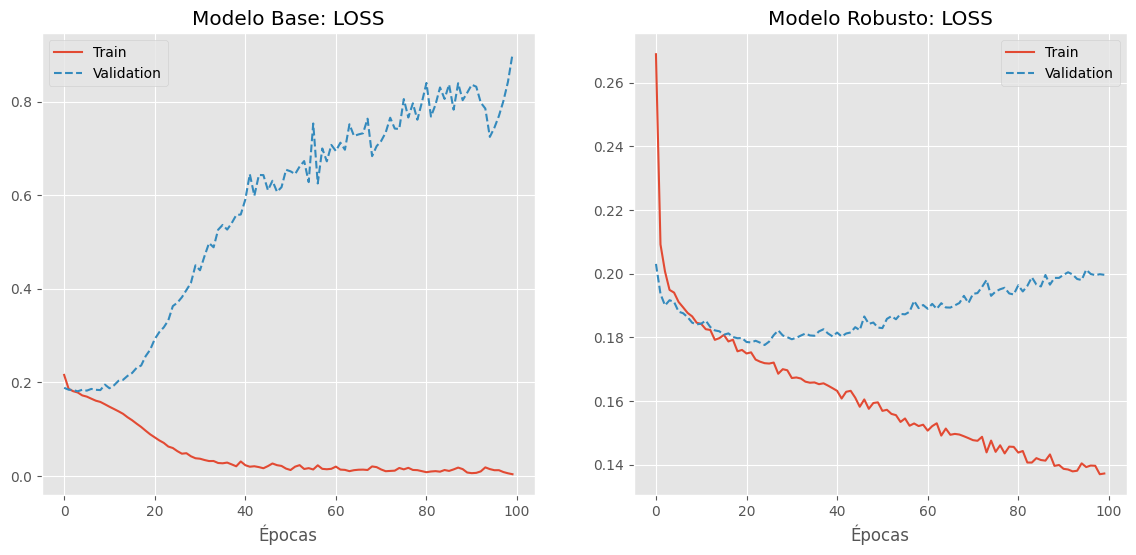

In [5]:
def plot_comparison(h_base, h_robust, metric='loss'):
    plt.figure(figsize=(14, 6))
    
    # Gráfico del Modelo Base
    plt.subplot(1, 2, 1)
    plt.plot(h_base.history[metric], label='Train')
    plt.plot(h_base.history[f'val_{metric}'], label='Validation', linestyle='--')
    plt.title(f'Modelo Base: {metric.upper()}')
    plt.xlabel('Épocas')
    plt.legend()
    
    # Gráfico del Modelo Robusto
    plt.subplot(1, 2, 2)
    plt.plot(h_robust.history[metric], label='Train')
    plt.plot(h_robust.history[f'val_{metric}'], label='Validation', linestyle='--')
    plt.title(f'Modelo Robusto: {metric.upper()}')
    plt.xlabel('Épocas')
    plt.legend()
    
    plt.show()

plot_comparison(history_base, history_robust, metric='loss')

**Interpretación:**
* En el **Modelo Base**, verán que la línea de Validación (punteada) empieza a subir en algún punto, mientras Train sigue bajando. ¡Alerta de Overfitting!
* En el **Modelo Robusto**, ambas líneas deberían mantenerse cercanas y descender juntas por más tiempo.

## 5. El Optimizador: Learning Rate Tuning

El "Learning Rate" es el hiperparámetro más crítico. Vamos a probar qué pasa si lo configuramos mal.

> Encapsulamiento `(get_compiled_model)`: Es una excelente práctica. Al crear un modelo nuevo en cada iteración, aseguras que cada entrenamiento empiece desde cero (pesos aleatorios) y no herede el aprendizaje del ciclo anterior.

Aquí, se aplica un for-loop sobre una lista con valores para el hiperparámetro "learning rate", luego entrena varias redes neuronales, luego pobla el diccionario "histories", y por último grafica la evolución de la función de pérdida a lo largo de las 30 épocas.

Entrenando con LR = 0.01...


c:\Users\HP ENVY\miniconda3\envs\mlnn2526\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando con LR = 0.001...


c:\Users\HP ENVY\miniconda3\envs\mlnn2526\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando con LR = 0.0001...


c:\Users\HP ENVY\miniconda3\envs\mlnn2526\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


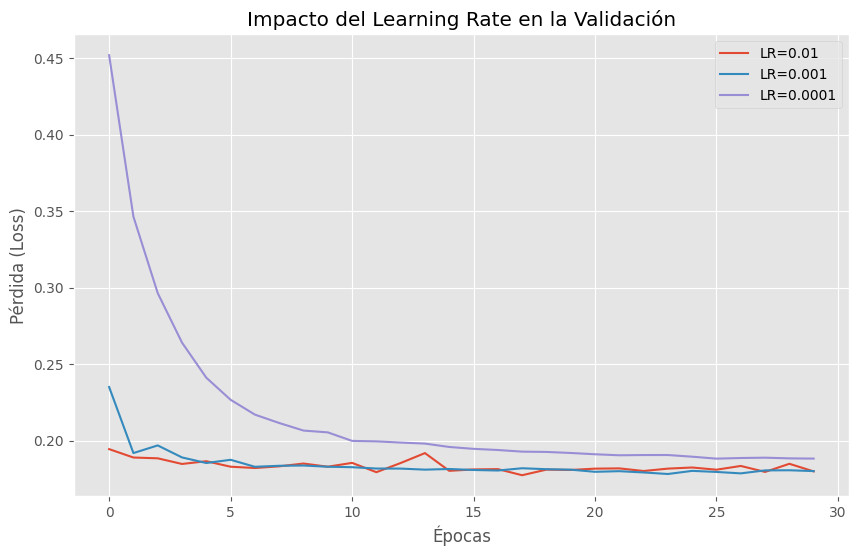

In [6]:
def get_compiled_model(lr):
    model = build_robust_model(INPUT_DIM)
    opt = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['AUC'])
    return model

# Probamos 3 escenarios
lrs = [0.01, 0.001, 0.0001]
histories = {}

for lr in lrs:
    print(f"Entrenando con LR = {lr}...")
    model = get_compiled_model(lr)
    h = model.fit(X_train, y_train, epochs=30, batch_size=128, validation_split=0.2, verbose=0)
    histories[lr] = h

# Visualizar impacto
plt.figure(figsize=(10, 6))
for lr, h in histories.items():
    plt.plot(h.history['val_loss'], label=f'LR={lr}')

plt.title('Impacto del Learning Rate en la Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.show()

¿Qué deberías esperar ver en la gráfica?
- **Si la curva sube y baja bruscamente**: El LR es demasiado alto (el modelo está "saltando" sobre el mínimo).

- **Si la curva es casi una línea recta horizontal**: El LR es demasiado bajo (el modelo está aprendiendo demasiado lento).

- **La curva ideal:** Una caída suave que se estabiliza (llega a una meseta) hacia el final de las 30 épocas.

## 6. Implementación Final: Early Stopping

Para el modelo de producción final, no queremos adivinar el número de épocas. Usaremos `EarlyStopping` para que la red se detenga sola cuando deje de mejorar.

In [9]:
final_model = build_robust_model(INPUT_DIM)
final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

# Callback de parada temprana

# (monitor='val_auc') --> Le dice al supervisor que se fije específicamente en el AUC de validación. 
# Si este número deja de subir, el supervisor empieza a sospechar que el modelo ya no está 
# aprendiendo nada útil.

# (patience=10) --> Es el margen de espera. 
# Si el val_auc no mejora durante 10 épocas consecutivas, el entrenamiento se detiene.

# (restore_best_weights=True) --> Normalmente, cuando el modelo se detiene por patience, 
# se queda con los pesos de la época final (que suelen ser peores). 
# Con esto activo, Keras retrocede en el tiempo y carga automáticamente 
# los pesos de la mejor época registrada.

# (verbose=1) --> Simplemente te avisará con un mensaje en la consola indicando 
# en qué época se detuvo el proceso.

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=10,        # Esperar 10 épocas antes de rendirse
    restore_best_weights=True, # Volver al mejor momento
    mode = 'max', # para indicarle que busque el máximo AUC
    verbose=1
)

# El parámetro callbacks en el método .fit es una lista. 
# Esto se debe a que puedes pasarle varios "asistentes" al mismo tiempo:
# --> ModelCheckpoint || ReduceLROnPlateau || EarlyStopping
# Durante el entrenamiento, Keras recorre esta lista al final de cada época y ejecuta las instrucciones 
# de cada objeto. En tu caso, solo consulta a early_stopping para saber si debe 
# continuar o detener el bucle de entrenamiento.

# Aquí callbacks ~ Asistentes o Supervisores

print("Entrenando modelo final con Early Stopping...")
final_history = final_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200, # Ponemos un número alto, sabiendo que parará antes
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

Entrenando modelo final con Early Stopping...
Epoch 1/200
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - AUC: 0.8353 - loss: 0.3304 - val_AUC: 0.9340 - val_loss: 0.2164
Epoch 2/200
 15/206 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AUC: 0.9163 - loss: 0.2141

c:\Users\HP ENVY\miniconda3\envs\mlnn2526\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)


206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.9172 - loss: 0.2154 - val_AUC: 0.9386 - val_loss: 0.1908
Epoch 3/200
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.9261 - loss: 0.2022 - val_AUC: 0.9415 - val_loss: 0.1867
Epoch 4/200
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.9294 - loss: 0.1973 - val_AUC: 0.9413 - val_loss: 0.1867
Epoch 5/200
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.9344 - loss: 0.1908 - val_AUC: 0.9428 - val_loss: 0.1831
Epoch 6/200
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.9346 - loss: 0.1910 - val_AUC: 0.9428 - val_loss: 0.1843
Epoch 7/200
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.9369 - loss: 0.1882 - val_AUC: 0.9419 - val_loss: 0.1844
Epoch 8/200
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.9377 - loss: 0.1870 - val_AUC: 0.9431 - val_loss: 0.1841
Epoch 9/200
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.9406 - loss: 0.1833 - val_AUC: 0.9444 - val_loss: 0.1811
Epoch 10/200
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC:

In [10]:
# Convertir el historial a un DataFrame
df_history = pd.DataFrame(final_history.history)

# Ver las últimas filas (incluyendo la 151)
print(df_history.tail())

          AUC      loss   val_AUC  val_loss
195  0.977731  0.116360  0.922311  0.233305
196  0.977373  0.117144  0.924576  0.231623
197  0.976547  0.118709  0.922837  0.230859
198  0.978249  0.115793  0.923449  0.230751
199  0.977735  0.116039  0.921608  0.232894


Text(0.5, 1.0, 'Historial de Entrenamiento con Early Stopping')

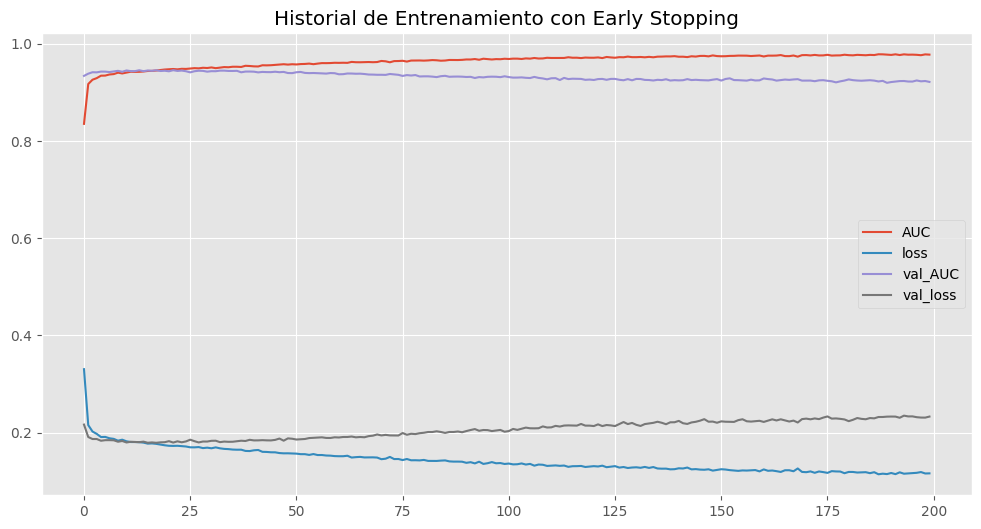

In [11]:
df_history.plot(figsize=(12, 6))
plt.title('Historial de Entrenamiento con Early Stopping')

In [13]:
2**9

512